In [1]:
import sys
import subprocess

try:
    import nltk
except ImportError:
    print('NLTK library not found. Installing it now...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

import os
import re
import time
import copy
import random
import unicodedata
from difflib import SequenceMatcher

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if not torch.cuda.is_available():
    torch.set_num_threads(4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# Special tokens
PAD_token = 0
SOS_token = 1
EOS_token = 2

# Files and folders
data_file = 'vast_english_french.txt'
problem1_split_file = os.path.join('Results_Problem_1', 'problem1_train_val_split.csv')
problem1_summary_file = os.path.join('Results_Problem_1', 'problem1_summary.csv')
problem2_summary_file = os.path.join('Results_Problem_2', 'problem2_summary.csv')
results_folder = 'Results_Problem_3'
os.makedirs(results_folder, exist_ok=True)

# Shared settings
batch_size = 96
max_generation_length = 90
beam_size = 3
decoding_length_factor = 1.25
metric_check_start = 15
metric_check_every = 5
metric_sample_size = 111
min_delta = 0.0002
min_learning_rate = 0.00005

# Baseline settings
baseline_hidden_size = 160
baseline_learning_rate = 0.010
baseline_weight_decay = 2e-5
baseline_dropout = 0.20
baseline_epochs = 120
baseline_scheduler_patience = 10
baseline_early_stop_patience = 35

# Attention settings
attention_hidden_size = 160
attention_learning_rate = 0.003
attention_weight_decay = 1e-5
attention_dropout = 0.08
attention_epochs = 110
attention_scheduler_patience = 16
attention_early_stop_patience = 40

print('batch_size:', batch_size)
print('beam_size:', beam_size)
print('baseline hidden:', baseline_hidden_size)
print('attention hidden:', attention_hidden_size)

batch_size: 96
beam_size: 3
baseline hidden: 160
attention hidden: 160


In [3]:
def clean_text(text):
    text = unicodedata.normalize('NFC', str(text).strip().lower())
    text = ''.join(ch for ch in text if ch.isprintable())
    text = re.sub(r'([.!?,])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def simple_key(text):
    text = clean_text(text)
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def read_translation_dataset(filename):
    sentence_pairs = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line == '':
                continue

            if '\t' in line:
                parts = line.split('\t')
            elif '|||' in line:
                parts = line.split('|||')
            else:
                parts = line.split(',', 1)

            if len(parts) >= 2:
                english = clean_text(parts[0])
                french = clean_text(parts[1])
                if english != '' and french != '':
                    sentence_pairs.append((english, french))
    return sentence_pairs


original_pairs = read_translation_dataset(data_file)
original_lookup = {simple_key(x[0]): x for x in original_pairs}

print('Total pairs:', len(original_pairs))
print('First pair:', original_pairs[0])

Total pairs: 555
First pair: ('i am cold', "j'ai froid")


In [4]:
# Same split membership as Problems 1 and 2, but reversed direction.
if os.path.exists(problem1_split_file):
    split_df = pd.read_csv(problem1_split_file)
    train_forward_pairs = []
    val_forward_pairs = []

    for _, row in split_df.iterrows():
        key = simple_key(row['english'])
        pair = original_lookup.get(key, (clean_text(row['english']), clean_text(row['french'])))

        if row['split'] == 'train':
            train_forward_pairs.append(pair)
        else:
            val_forward_pairs.append(pair)

    print('Loaded split membership from Problem 1.')
else:
    all_indices = list(range(len(original_pairs)))
    random.Random(seed).shuffle(all_indices)
    split_point = int(0.80 * len(all_indices))
    train_forward_pairs = [original_pairs[i] for i in all_indices[:split_point]]
    val_forward_pairs = [original_pairs[i] for i in all_indices[split_point:]]
    print('Problem 1 split was not found, so a seeded 80/20 split was made.')

# Reverse direction: French input -> English target.
train_dataset_pairs = [(french, english) for english, french in train_forward_pairs]
val_dataset_pairs = [(french, english) for english, french in val_forward_pairs]
default_direction = 'French to English'

print('Training pairs:', len(train_dataset_pairs))
print('Validation pairs:', len(val_dataset_pairs))
print('Example reversed pair:', train_dataset_pairs[0])

split_out = pd.DataFrame(
    [{'split': 'train', 'source_french': x[0], 'target_english': x[1]} for x in train_dataset_pairs] +
    [{'split': 'val', 'source_french': x[0], 'target_english': x[1]} for x in val_dataset_pairs]
)
split_out.to_csv(os.path.join(results_folder, 'problem3_reversed_train_val_split.csv'), index=False)
split_out.head()

Loaded split membership from Problem 1.
Training pairs: 444
Validation pairs: 111
Example reversed pair: ('il enseigne la géographie mondiale à des classes de lycée', 'he teaches world geography to high school classes')


,split,source_french,target_english
0,train,il enseigne la géographie mondiale à des class...,he teaches world geography to high school classes
1,train,il joue de la basse dans un groupe de jazz pro...,he plays bass guitar in a professional jazz band
2,train,les prévisions météo annoncent de fortes chute...,the weather forecast predicts heavy snow tomorrow
3,train,elle adore porter de longues jupes amples en c...,she loves to wear long flowing cotton skirts
4,train,ils écoutent le professeur avec une attention ...,they listen to the professor with absolute att...


In [5]:
# Vocabulary is shared by source and target characters.
all_reversed_pairs = train_dataset_pairs + val_dataset_pairs
unique_chars = sorted(list(set(''.join([word for pair in all_reversed_pairs for word in pair]))))

char_to_index = {'PAD': PAD_token, 'SOS': SOS_token, 'EOS': EOS_token}
for i, char in enumerate(unique_chars):
    char_to_index[char] = i + 3

index_to_char = {i: char for char, i in char_to_index.items()}
input_size = len(char_to_index)
output_size = len(char_to_index)

print('Vocabulary size:', len(char_to_index))
print('Some characters:', unique_chars[:25])


def sentence_to_indexes(sentence):
    return [char_to_index[char] for char in str(sentence)] + [EOS_token]


def make_batches(data_pairs, batch_size=64, shuffle=True):
    data_pairs = data_pairs[:]
    if shuffle:
        random.shuffle(data_pairs)

    for start in range(0, len(data_pairs), batch_size):
        batch_pairs = data_pairs[start:start + batch_size]
        input_list = [sentence_to_indexes(x[0]) for x in batch_pairs]
        target_list = [sentence_to_indexes(x[1]) for x in batch_pairs]

        max_input_len = max(len(x) for x in input_list)
        max_target_len = max(len(x) for x in target_list)
        input_lengths = torch.tensor([len(x) for x in input_list], dtype=torch.long, device=device)

        input_batch = torch.full((len(batch_pairs), max_input_len), PAD_token, dtype=torch.long)
        target_batch = torch.full((len(batch_pairs), max_target_len), PAD_token, dtype=torch.long)

        for i in range(len(batch_pairs)):
            input_batch[i, :len(input_list[i])] = torch.tensor(input_list[i], dtype=torch.long)
            target_batch[i, :len(target_list[i])] = torch.tensor(target_list[i], dtype=torch.long)

        yield input_batch.to(device), target_batch.to(device), input_lengths, batch_pairs

Vocabulary size: 49
Some characters: [' ', "'", ',', '-', '1', '7', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']


In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def character_accuracy(target_string, predicted_string):
    if len(target_string) == 0 and len(predicted_string) == 0:
        return 1.0
    max_len = max(len(target_string), len(predicted_string))
    correct_chars = 0
    for i in range(max_len):
        if i < len(target_string) and i < len(predicted_string):
            if target_string[i] == predicted_string[i]:
                correct_chars += 1
    return correct_chars / max_len


def sequence_similarity(target_string, predicted_string):
    return SequenceMatcher(None, target_string, predicted_string).ratio()


def compute_text_metrics(data_pairs, predict_function):
    chencherry = SmoothingFunction()
    rows = []
    exact_count = 0
    total_char_accuracy = 0.0
    total_sequence_similarity = 0.0
    total_char_bleu = 0.0
    total_word_bleu = 0.0

    for source_string, target_string in data_pairs:
        predicted_string = predict_function(source_string)
        exact_match = predicted_string == target_string

        char_acc = character_accuracy(target_string, predicted_string)
        seq_sim = sequence_similarity(target_string, predicted_string)
        char_bleu = sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=chencherry.method1)
        word_bleu = sentence_bleu([target_string.split()], predicted_string.split(), smoothing_function=chencherry.method1)

        if exact_match:
            exact_count += 1
        total_char_accuracy += char_acc
        total_sequence_similarity += seq_sim
        total_char_bleu += char_bleu
        total_word_bleu += word_bleu

        rows.append({
            'input_french': source_string,
            'target_english': target_string,
            'predicted_english': predicted_string,
            'exact_match': 'PASS' if exact_match else 'FAIL',
            'char_accuracy': char_acc,
            'sequence_similarity': seq_sim,
            'char_bleu4': char_bleu,
            'word_bleu4': word_bleu
        })

    n = len(data_pairs)
    metrics = {
        'traditional_sequence_accuracy': exact_count / n,
        'validation_character_accuracy': total_char_accuracy / n,
        'validation_sequence_similarity': total_sequence_similarity / n,
        'validation_bleu4_char_level': total_char_bleu / n,
        'validation_bleu4_word_level': total_word_bleu / n,
        'exact_count': exact_count,
        'total_count': n
    }
    return metrics, pd.DataFrame(rows)

## Part A: Reversed Baseline GRU Encoder-Decoder

In [7]:
class BaselineEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(BaselineEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input_batch, input_lengths):
        embedded = self.dropout(self.embedding(input_batch))
        output, hidden_state = self.gru(embedded)
        batch_numbers = torch.arange(input_batch.size(0), device=device)
        last_outputs = output[batch_numbers, input_lengths - 1]
        hidden_state = last_outputs.unsqueeze(0)
        return output, hidden_state


class BaselineDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_prob):
        super(BaselineDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)

    def forward(self, input_batch, hidden_state):
        embedded = self.dropout(self.embedding(input_batch))
        output, hidden_state = self.gru(embedded, hidden_state)
        output = self.softmax(self.out(output))
        return output, hidden_state

In [8]:
def train_baseline_model():
    encoder = BaselineEncoder(input_size, baseline_hidden_size, baseline_dropout).to(device)
    decoder = BaselineDecoder(baseline_hidden_size, output_size, baseline_dropout).to(device)

    all_params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = optim.Adam(all_params, lr=baseline_learning_rate, weight_decay=baseline_weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=baseline_scheduler_patience, threshold=min_delta, min_lr=min_learning_rate
    )
    criterion = nn.NLLLoss(ignore_index=PAD_token)

    def run_one_epoch(data_pairs, training=True):
        encoder.train(training)
        decoder.train(training)
        total_loss = 0.0
        total_batches = 0

        for input_batch, target_batch, input_lengths, batch_pairs in make_batches(data_pairs, batch_size=batch_size, shuffle=training):
            if training:
                optimizer.zero_grad()

            encoder_output, encoder_hidden = encoder(input_batch, input_lengths)
            sos_column = torch.full((target_batch.size(0), 1), SOS_token, dtype=torch.long, device=device)
            decoder_input = torch.cat([sos_column, target_batch[:, :-1]], dim=1)
            decoder_output, decoder_hidden = decoder(decoder_input, encoder_hidden)
            loss = criterion(decoder_output.reshape(-1, output_size), target_batch.reshape(-1))

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(all_params, 1.0)
                optimizer.step()

            total_loss += loss.item()
            total_batches += 1
        return total_loss / total_batches

    def predict(source_string, local_beam_size=beam_size):
        encoder.eval()
        decoder.eval()
        source_string = clean_text(source_string)
        input_indexes = sentence_to_indexes(source_string)
        input_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)
        input_lengths = torch.tensor([len(input_indexes)], dtype=torch.long, device=device)
        local_max_length = min(max_generation_length, max(10, int(len(source_string) * decoding_length_factor) + 6))

        with torch.no_grad():
            encoder_output, encoder_hidden = encoder(input_tensor, input_lengths)
            beams = [([], 0.0, encoder_hidden, torch.tensor([[SOS_token]], dtype=torch.long, device=device), False)]

            for di in range(local_max_length):
                new_beams = []
                for seq, score, hidden_state, decoder_input, done in beams:
                    if done:
                        new_beams.append((seq, score, hidden_state, decoder_input, done))
                        continue

                    decoder_output, new_hidden = decoder(decoder_input, hidden_state)
                    topv, topi = decoder_output[:, -1, :].topk(local_beam_size)

                    for j in range(local_beam_size):
                        idx_pred = topi[0, j].item()
                        new_seq = seq + [idx_pred]
                        new_score = score + topv[0, j].item()

                        if len(new_seq) >= 6 and new_seq[-3:] == new_seq[-6:-3]:
                            new_score -= 1.2
                        if len(new_seq) >= 8 and new_seq[-4:] == new_seq[-8:-4]:
                            new_score -= 1.5

                        new_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)
                        new_beams.append((new_seq, new_score, new_hidden, new_input, idx_pred == EOS_token))

                beams = sorted(new_beams, key=lambda x: x[1] / ((len(x[0]) + 1) ** 0.7), reverse=True)[:local_beam_size]
                if all(x[4] for x in beams):
                    break

        best_seq = beams[0][0]
        return ''.join([index_to_char[idx] for idx in best_seq if idx not in (PAD_token, SOS_token, EOS_token)])

    def quick_validation_score():
        sample_pairs = val_dataset_pairs[:metric_sample_size]
        metrics, temp_df = compute_text_metrics(sample_pairs, predict)
        score = metrics['validation_bleu4_char_level'] + 0.25 * metrics['validation_sequence_similarity']
        return score, metrics['validation_bleu4_char_level'], metrics['validation_sequence_similarity']

    train_losses = []
    val_losses = []
    lr_history = []
    metric_epochs = []
    metric_scores = []
    metric_bleus = []
    metric_similarities = []

    best_val_loss = 999999
    best_loss_epoch = 0
    best_loss_encoder_state = None
    best_loss_decoder_state = None

    best_metric_score = -1
    best_metric_epoch = 0
    best_metric_bleu = 0
    best_metric_similarity = 0
    best_metric_encoder_state = None
    best_metric_decoder_state = None

    no_improve_count = 0
    start_time = time.time()

    print('Starting reversed baseline training...')
    for epoch in range(baseline_epochs):
        train_loss = run_one_epoch(train_dataset_pairs, training=True)
        with torch.no_grad():
            val_loss = run_one_epoch(val_dataset_pairs, training=False)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_loss_epoch = epoch
            best_loss_encoder_state = copy.deepcopy(encoder.state_dict())
            best_loss_decoder_state = copy.deepcopy(decoder.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if epoch >= metric_check_start and epoch % metric_check_every == 0:
            metric_score, metric_bleu, metric_similarity = quick_validation_score()
            metric_epochs.append(epoch)
            metric_scores.append(metric_score)
            metric_bleus.append(metric_bleu)
            metric_similarities.append(metric_similarity)

            if metric_score > best_metric_score:
                best_metric_score = metric_score
                best_metric_epoch = epoch
                best_metric_bleu = metric_bleu
                best_metric_similarity = metric_similarity
                best_metric_encoder_state = copy.deepcopy(encoder.state_dict())
                best_metric_decoder_state = copy.deepcopy(decoder.state_dict())

            print(f'Baseline Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Sample BLEU: {metric_bleu:.4f} | Sample Sim: {metric_similarity:.4f}')
        elif epoch % 10 == 0:
            print(f'Baseline Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}')

        if no_improve_count >= baseline_early_stop_patience:
            print('Baseline early stopping at epoch:', epoch)
            break

    training_time = time.time() - start_time
    actual_epochs = len(train_losses)

    if best_metric_encoder_state is not None:
        encoder.load_state_dict(best_metric_encoder_state)
        decoder.load_state_dict(best_metric_decoder_state)
        checkpoint_type = 'best sampled BLEU/similarity checkpoint'
    else:
        encoder.load_state_dict(best_loss_encoder_state)
        decoder.load_state_dict(best_loss_decoder_state)
        checkpoint_type = 'best validation-loss checkpoint'

    return {
        'model_name': 'Reversed Baseline GRU',
        'encoder': encoder,
        'decoder': decoder,
        'predict': predict,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lr_history': lr_history,
        'metric_history': pd.DataFrame({
            'epoch': metric_epochs,
            'sample_metric_score': metric_scores,
            'sample_char_bleu4': metric_bleus,
            'sample_sequence_similarity': metric_similarities
        }),
        'training_time': training_time,
        'actual_epochs': actual_epochs,
        'best_val_loss': best_val_loss,
        'best_loss_epoch': best_loss_epoch,
        'checkpoint_type': checkpoint_type,
        'best_metric_epoch': best_metric_epoch,
        'best_metric_bleu': best_metric_bleu,
        'best_metric_similarity': best_metric_similarity,
        'encoder_params': count_parameters(encoder),
        'decoder_params': count_parameters(decoder),
        'final_lr': optimizer.param_groups[0]['lr']
    }


baseline_info = train_baseline_model()

Starting reversed baseline training...
Baseline Epoch 000 | Train Loss: 3.0178 | Val Loss: 2.4362 | LR: 0.010000
Baseline Epoch 010 | Train Loss: 1.4825 | Val Loss: 1.5983 | LR: 0.010000
Baseline Epoch 015 | Train Loss: 1.2147 | Val Loss: 1.4654 | Sample BLEU: 0.1512 | Sample Sim: 0.3845
Baseline Epoch 020 | Train Loss: 1.0132 | Val Loss: 1.3891 | Sample BLEU: 0.1606 | Sample Sim: 0.4019
Baseline Epoch 025 | Train Loss: 0.8539 | Val Loss: 1.3979 | Sample BLEU: 0.1529 | Sample Sim: 0.3934
Baseline Epoch 030 | Train Loss: 0.7190 | Val Loss: 1.4110 | Sample BLEU: 0.1657 | Sample Sim: 0.4070
Baseline Epoch 035 | Train Loss: 0.5997 | Val Loss: 1.4236 | Sample BLEU: 0.1621 | Sample Sim: 0.3899
Baseline Epoch 040 | Train Loss: 0.5171 | Val Loss: 1.4565 | Sample BLEU: 0.1711 | Sample Sim: 0.3972
Baseline Epoch 045 | Train Loss: 0.4601 | Val Loss: 1.4996 | Sample BLEU: 0.1529 | Sample Sim: 0.3831
Baseline Epoch 050 | Train Loss: 0.4092 | Val Loss: 1.5079 | Sample BLEU: 0.1619 | Sample Sim: 0.38

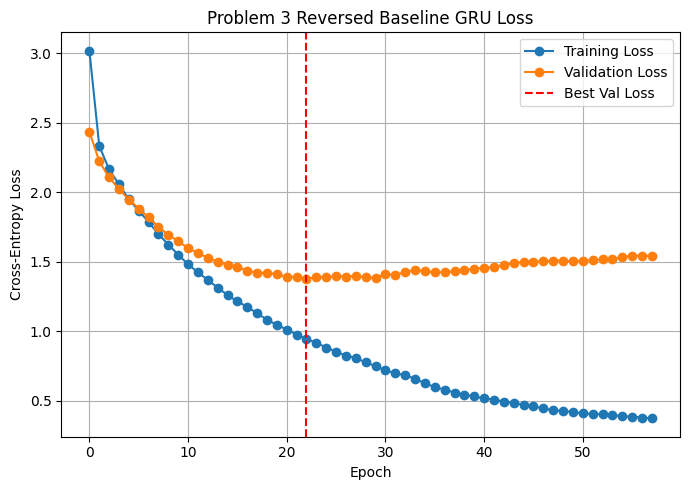

--- Problem 3 Reversed Baseline GRU Validation Results ---
Exact accuracy: 0.0 %
Character accuracy: 18.13 %
Sequence similarity: 39.72 %
Character BLEU-4: 0.1711
Word BLEU-4: 0.0623
                                       input_french                                 target_english                               predicted_english exact_match  char_accuracy  sequence_similarity  char_bleu4  word_bleu4
           ils nourrissent les pigeons sur la place            they feed the pigeons in the square                they play tennis on the weekends        FAIL       0.200000             0.537313    0.317373    0.041096
              elle pratique le yoga tous les matins               she practices yoga every morning                 she translates legal agreements        FAIL       0.218750             0.539683    0.148694    0.062571
                       j'aime marcher dans la neige                    i enjoy walking in the snow                     i look forward to the party        FAIL  

In [9]:
def save_model_results(info, prefix, title):
    plt.figure(figsize=(7, 5))
    plt.plot(info['train_losses'], marker='o', label='Training Loss')
    plt.plot(info['val_losses'], marker='o', label='Validation Loss')
    plt.axvline(info['best_loss_epoch'], color='red', linestyle='--', label='Best Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(title + ' Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder, prefix + '_loss_curve.png'), dpi=200, bbox_inches='tight')
    plt.show()

    history_df = pd.DataFrame({
        'epoch': list(range(len(info['train_losses']))),
        'train_loss': info['train_losses'],
        'validation_loss': info['val_losses'],
        'learning_rate': info['lr_history']
    })
    history_df.to_csv(os.path.join(results_folder, prefix + '_training_history.csv'), index=False)
    info['metric_history'].to_csv(os.path.join(results_folder, prefix + '_metric_history.csv'), index=False)

    metrics, results_df = compute_text_metrics(val_dataset_pairs, info['predict'])
    results_df.to_csv(os.path.join(results_folder, prefix + '_validation_results.csv'), index=False)
    results_df.head(5).to_csv(os.path.join(results_folder, prefix + '_sample_translations.csv'), index=False)

    print('---', title, 'Validation Results ---')
    print('Exact accuracy:', round(metrics['traditional_sequence_accuracy'] * 100, 2), '%')
    print('Character accuracy:', round(metrics['validation_character_accuracy'] * 100, 2), '%')
    print('Sequence similarity:', round(metrics['validation_sequence_similarity'] * 100, 2), '%')
    print('Character BLEU-4:', round(metrics['validation_bleu4_char_level'], 4))
    print('Word BLEU-4:', round(metrics['validation_bleu4_word_level'], 4))
    print(results_df.head(5).to_string(index=False))

    summary_row = {
        'model': info['model_name'],
        'direction': default_direction,
        'seed': seed,
        'train_size': len(train_dataset_pairs),
        'validation_size': len(val_dataset_pairs),
        'checkpoint_type': info['checkpoint_type'],
        'best_metric_epoch': info['best_metric_epoch'],
        'best_sampled_bleu4': info['best_metric_bleu'],
        'best_sampled_similarity': info['best_metric_similarity'],
        'epochs_run': info['actual_epochs'],
        'best_loss_epoch': info['best_loss_epoch'],
        'best_validation_loss': info['best_val_loss'],
        'final_learning_rate': info['final_lr'],
        'traditional_sequence_accuracy': metrics['traditional_sequence_accuracy'],
        'validation_character_accuracy': metrics['validation_character_accuracy'],
        'validation_sequence_similarity': metrics['validation_sequence_similarity'],
        'validation_bleu4_char_level': metrics['validation_bleu4_char_level'],
        'validation_bleu4_word_level': metrics['validation_bleu4_word_level'],
        'training_time_sec': info['training_time'],
        'encoder_params': info['encoder_params'],
        'decoder_params': info['decoder_params'],
        'total_params': info['encoder_params'] + info['decoder_params'],
        'hardware': str(device)
    }
    return summary_row, results_df


baseline_summary, baseline_results_df = save_model_results(
    baseline_info,
    'problem3_baseline',
    'Problem 3 Reversed Baseline GRU'
)

## Part B: Reversed GRU Encoder-Decoder with Attention

In [10]:
class AttentionEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(AttentionEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)
        self.bridge = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, input_batch, input_lengths):
        embedded = self.dropout(self.embedding(input_batch))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            input_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_outputs, hidden_state = self.gru(packed)
        encoder_outputs, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        hidden_cat = torch.cat((hidden_state[-2], hidden_state[-1]), dim=1)
        decoder_start = torch.tanh(self.bridge(hidden_cat)).unsqueeze(0)
        return encoder_outputs, decoder_start


class AttentionDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_prob):
        super(AttentionDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.encoder_size = hidden_size * 2
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.encoder_project = nn.Linear(self.encoder_size, hidden_size)
        self.attn_combine = nn.Linear(hidden_size + self.encoder_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)

    def forward(self, input_batch, hidden_state, encoder_outputs, input_mask):
        embedded = self.dropout(self.embedding(input_batch))
        decoder_outputs, hidden_state = self.gru(embedded, hidden_state)

        projected_encoder = self.encoder_project(encoder_outputs)
        attn_scores = torch.bmm(decoder_outputs, projected_encoder.transpose(1, 2))
        attn_scores = attn_scores.masked_fill(input_mask.unsqueeze(1) == 0, -1000000000.0)
        attn_weights = torch.softmax(attn_scores, dim=2)
        context = torch.bmm(attn_weights, encoder_outputs)

        combined = torch.cat((decoder_outputs, context), dim=2)
        combined = torch.tanh(self.attn_combine(combined))
        output = self.softmax(self.out(combined))
        return output, hidden_state, attn_weights

In [11]:
def train_attention_model():
    encoder = AttentionEncoder(input_size, attention_hidden_size, attention_dropout).to(device)
    decoder = AttentionDecoder(attention_hidden_size, output_size, attention_dropout).to(device)

    all_params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = optim.Adam(all_params, lr=attention_learning_rate, weight_decay=attention_weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=attention_scheduler_patience, threshold=min_delta, min_lr=min_learning_rate
    )
    criterion = nn.NLLLoss(ignore_index=PAD_token)

    def run_one_epoch(data_pairs, training=True):
        encoder.train(training)
        decoder.train(training)
        total_loss = 0.0
        total_batches = 0

        for input_batch, target_batch, input_lengths, batch_pairs in make_batches(data_pairs, batch_size=batch_size, shuffle=training):
            if training:
                optimizer.zero_grad()

            encoder_outputs, encoder_hidden = encoder(input_batch, input_lengths)
            input_mask = torch.arange(encoder_outputs.size(1), device=device).unsqueeze(0) < input_lengths.unsqueeze(1)

            sos_column = torch.full((target_batch.size(0), 1), SOS_token, dtype=torch.long, device=device)
            decoder_input = torch.cat([sos_column, target_batch[:, :-1]], dim=1)
            decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, encoder_hidden, encoder_outputs, input_mask)
            loss = criterion(decoder_output.reshape(-1, output_size), target_batch.reshape(-1))

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(all_params, 1.0)
                optimizer.step()

            total_loss += loss.item()
            total_batches += 1
        return total_loss / total_batches

    def predict(source_string, return_attention=False, local_beam_size=beam_size):
        encoder.eval()
        decoder.eval()
        source_string = clean_text(source_string)
        input_indexes = sentence_to_indexes(source_string)
        input_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)
        input_lengths = torch.tensor([len(input_indexes)], dtype=torch.long, device=device)
        local_max_length = min(max_generation_length, max(10, int(len(source_string) * decoding_length_factor) + 6))

        with torch.no_grad():
            encoder_outputs, encoder_hidden = encoder(input_tensor, input_lengths)
            input_mask = torch.arange(encoder_outputs.size(1), device=device).unsqueeze(0) < input_lengths.unsqueeze(1)

            if return_attention:
                decoder_hidden = encoder_hidden
                decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
                predicted_indices = []
                attention_rows = []
                for di in range(local_max_length):
                    decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs, input_mask)
                    topv, topi = decoder_output[:, -1, :].topk(1)
                    idx_pred = topi.item()
                    attention_rows.append(attn_weights[0, -1, :len(input_indexes)].detach().cpu().numpy())
                    if idx_pred == EOS_token:
                        break
                    if idx_pred not in (PAD_token, SOS_token):
                        predicted_indices.append(idx_pred)
                    decoder_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)

                predicted_string = ''.join([index_to_char[idx] for idx in predicted_indices])
                source_chars = [index_to_char[idx] for idx in input_indexes if idx != EOS_token]
                predicted_chars = [index_to_char[idx] for idx in predicted_indices]
                return predicted_string, np.array(attention_rows), source_chars, predicted_chars

            beams = [([], 0.0, encoder_hidden, torch.tensor([[SOS_token]], dtype=torch.long, device=device), False)]
            for di in range(local_max_length):
                new_beams = []
                for seq, score, hidden_state, decoder_input, done in beams:
                    if done:
                        new_beams.append((seq, score, hidden_state, decoder_input, done))
                        continue

                    decoder_output, new_hidden, attn_weights = decoder(decoder_input, hidden_state, encoder_outputs, input_mask)
                    topv, topi = decoder_output[:, -1, :].topk(local_beam_size)

                    for j in range(local_beam_size):
                        idx_pred = topi[0, j].item()
                        new_seq = seq + [idx_pred]
                        new_score = score + topv[0, j].item()

                        if len(new_seq) >= 6 and new_seq[-3:] == new_seq[-6:-3]:
                            new_score -= 1.2
                        if len(new_seq) >= 8 and new_seq[-4:] == new_seq[-8:-4]:
                            new_score -= 1.5

                        new_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)
                        new_beams.append((new_seq, new_score, new_hidden, new_input, idx_pred == EOS_token))

                beams = sorted(new_beams, key=lambda x: x[1] / ((len(x[0]) + 1) ** 0.7), reverse=True)[:local_beam_size]
                if all(x[4] for x in beams):
                    break

        best_seq = beams[0][0]
        return ''.join([index_to_char[idx] for idx in best_seq if idx not in (PAD_token, SOS_token, EOS_token)])

    def quick_validation_score():
        sample_pairs = val_dataset_pairs[:metric_sample_size]
        metrics, temp_df = compute_text_metrics(sample_pairs, predict)
        score = metrics['validation_bleu4_char_level'] + 0.25 * metrics['validation_sequence_similarity']
        return score, metrics['validation_bleu4_char_level'], metrics['validation_sequence_similarity']

    train_losses = []
    val_losses = []
    lr_history = []
    metric_epochs = []
    metric_scores = []
    metric_bleus = []
    metric_similarities = []

    best_val_loss = 999999
    best_loss_epoch = 0
    best_loss_encoder_state = None
    best_loss_decoder_state = None

    best_metric_score = -1
    best_metric_epoch = 0
    best_metric_bleu = 0
    best_metric_similarity = 0
    best_metric_encoder_state = None
    best_metric_decoder_state = None

    no_improve_count = 0
    start_time = time.time()

    print('Starting reversed attention training...')
    for epoch in range(attention_epochs):
        train_loss = run_one_epoch(train_dataset_pairs, training=True)
        with torch.no_grad():
            val_loss = run_one_epoch(val_dataset_pairs, training=False)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_loss_epoch = epoch
            best_loss_encoder_state = copy.deepcopy(encoder.state_dict())
            best_loss_decoder_state = copy.deepcopy(decoder.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if epoch >= metric_check_start and epoch % metric_check_every == 0:
            metric_score, metric_bleu, metric_similarity = quick_validation_score()
            metric_epochs.append(epoch)
            metric_scores.append(metric_score)
            metric_bleus.append(metric_bleu)
            metric_similarities.append(metric_similarity)

            if metric_score > best_metric_score:
                best_metric_score = metric_score
                best_metric_epoch = epoch
                best_metric_bleu = metric_bleu
                best_metric_similarity = metric_similarity
                best_metric_encoder_state = copy.deepcopy(encoder.state_dict())
                best_metric_decoder_state = copy.deepcopy(decoder.state_dict())

            print(f'Attention Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Sample BLEU: {metric_bleu:.4f} | Sample Sim: {metric_similarity:.4f}')
        elif epoch % 10 == 0:
            print(f'Attention Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}')

        if no_improve_count >= attention_early_stop_patience:
            print('Attention early stopping at epoch:', epoch)
            break

    training_time = time.time() - start_time
    actual_epochs = len(train_losses)

    if best_metric_encoder_state is not None:
        encoder.load_state_dict(best_metric_encoder_state)
        decoder.load_state_dict(best_metric_decoder_state)
        checkpoint_type = 'best sampled BLEU/similarity checkpoint'
    else:
        encoder.load_state_dict(best_loss_encoder_state)
        decoder.load_state_dict(best_loss_decoder_state)
        checkpoint_type = 'best validation-loss checkpoint'

    return {
        'model_name': 'Reversed Attention GRU',
        'encoder': encoder,
        'decoder': decoder,
        'predict': predict,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lr_history': lr_history,
        'metric_history': pd.DataFrame({
            'epoch': metric_epochs,
            'sample_metric_score': metric_scores,
            'sample_char_bleu4': metric_bleus,
            'sample_sequence_similarity': metric_similarities
        }),
        'training_time': training_time,
        'actual_epochs': actual_epochs,
        'best_val_loss': best_val_loss,
        'best_loss_epoch': best_loss_epoch,
        'checkpoint_type': checkpoint_type,
        'best_metric_epoch': best_metric_epoch,
        'best_metric_bleu': best_metric_bleu,
        'best_metric_similarity': best_metric_similarity,
        'encoder_params': count_parameters(encoder),
        'decoder_params': count_parameters(decoder),
        'final_lr': optimizer.param_groups[0]['lr']
    }


attention_info = train_attention_model()

Starting reversed attention training...
Attention Epoch 000 | Train Loss: 3.2859 | Val Loss: 2.8644 | LR: 0.003000
Attention Epoch 010 | Train Loss: 1.8151 | Val Loss: 1.8381 | LR: 0.003000
Attention Epoch 015 | Train Loss: 1.4988 | Val Loss: 1.6579 | Sample BLEU: 0.1096 | Sample Sim: 0.3568
Attention Epoch 020 | Train Loss: 1.2046 | Val Loss: 1.5552 | Sample BLEU: 0.1302 | Sample Sim: 0.3793
Attention Epoch 025 | Train Loss: 0.9369 | Val Loss: 1.4924 | Sample BLEU: 0.1318 | Sample Sim: 0.3966
Attention Epoch 030 | Train Loss: 0.7205 | Val Loss: 1.4903 | Sample BLEU: 0.1564 | Sample Sim: 0.4115
Attention Epoch 035 | Train Loss: 0.5497 | Val Loss: 1.5288 | Sample BLEU: 0.1780 | Sample Sim: 0.4268
Attention Epoch 040 | Train Loss: 0.4108 | Val Loss: 1.5775 | Sample BLEU: 0.1823 | Sample Sim: 0.4241
Attention Epoch 045 | Train Loss: 0.2945 | Val Loss: 1.6004 | Sample BLEU: 0.1940 | Sample Sim: 0.4435
Attention Epoch 050 | Train Loss: 0.2205 | Val Loss: 1.6577 | Sample BLEU: 0.1936 | Sampl

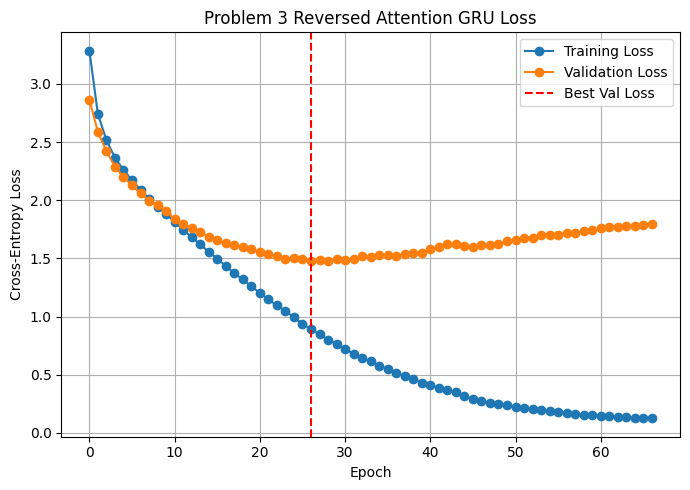

--- Problem 3 Reversed Attention GRU Validation Results ---
Exact accuracy: 0.0 %
Character accuracy: 20.83 %
Sequence similarity: 44.35 %
Character BLEU-4: 0.194
Word BLEU-4: 0.0726
                                       input_french                                 target_english    predicted_english exact_match  char_accuracy  sequence_similarity  char_bleu4  word_bleu4
           ils nourrissent les pigeons sur la place            they feed the pigeons in the square   they feed the park        FAIL       0.428571             0.641509    0.333631    0.187830
              elle pratique le yoga tous les matins               she practices yoga every morning        she play long        FAIL       0.187500             0.488889    0.090377    0.058335
                       j'aime marcher dans la neige                    i enjoy walking in the snow   i look for holiday        FAIL       0.074074             0.177778    0.021685    0.048730
              elle adore porter des vestes modern

In [12]:
attention_summary, attention_results_df = save_model_results(
    attention_info,
    'problem3_attention',
    'Problem 3 Reversed Attention GRU'
)

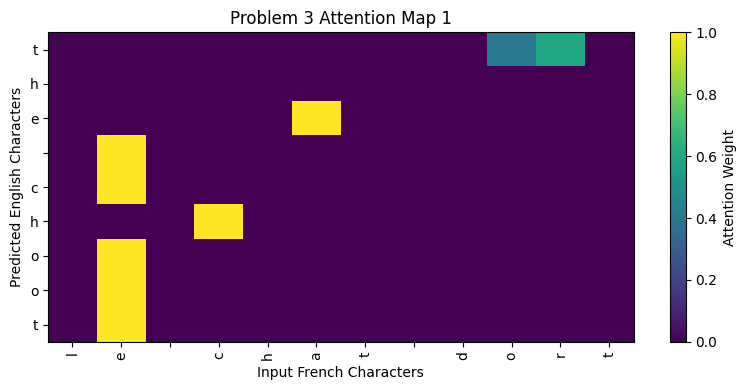

French input: le chat dort
Target English: the cat is sleeping
Predicted English: the choot
Saved: Results_Problem_3\problem3_attention_map_1.png


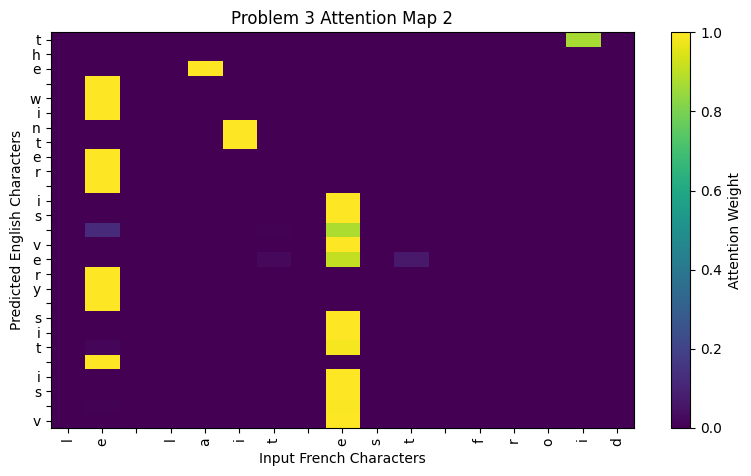

French input: le lait est froid
Target English: the milk is cold
Predicted English: the winter is very sit is v
Saved: Results_Problem_3\problem3_attention_map_2.png


In [13]:
# Attention map visualizations for reversed direction.
short_examples = sorted(val_dataset_pairs, key=lambda x: len(x[0]) + len(x[1]))[:2]

for map_num, (source_french, target_english) in enumerate(short_examples, start=1):
    predicted_english, attention_matrix, source_chars, predicted_chars = attention_info['predict'](
        source_french,
        return_attention=True
    )

    if len(predicted_chars) == 0:
        predicted_chars = [' ']
        attention_matrix = np.zeros((1, len(source_chars)))

    plt.figure(figsize=(max(8, len(source_chars) * 0.35), max(4, len(predicted_chars) * 0.18)))
    plt.imshow(attention_matrix[:len(predicted_chars), :len(source_chars)], aspect='auto', cmap='viridis')
    plt.colorbar(label='Attention Weight')
    plt.xticks(range(len(source_chars)), source_chars, rotation=90)
    plt.yticks(range(len(predicted_chars)), predicted_chars)
    plt.xlabel('Input French Characters')
    plt.ylabel('Predicted English Characters')
    plt.title('Problem 3 Attention Map ' + str(map_num))
    plt.tight_layout()
    out_file = os.path.join(results_folder, 'problem3_attention_map_' + str(map_num) + '.png')
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.show()

    print('French input:', source_french)
    print('Target English:', target_english)
    print('Predicted English:', predicted_english)
    print('Saved:', out_file)

In [14]:
summary_df = pd.DataFrame([baseline_summary, attention_summary])
summary_df.to_csv(os.path.join(results_folder, 'problem3_summary.csv'), index=False)
summary_df

,model,direction,seed,train_size,validation_size,checkpoint_type,best_metric_epoch,best_sampled_bleu4,best_sampled_similarity,epochs_run,...,traditional_sequence_accuracy,validation_character_accuracy,validation_sequence_similarity,validation_bleu4_char_level,validation_bleu4_word_level,training_time_sec,encoder_params,decoder_params,total_params,hardware
0,Reversed Baseline GRU,French to English,42,444,111,best sampled BLEU/similarity checkpoint,40,0.171086,0.397232,58,...,0.0,0.181316,0.397232,0.171086,0.062269,202.588634,162400,170289,332689,cpu
1,Reversed Attention GRU,French to English,42,444,111,best sampled BLEU/similarity checkpoint,45,0.194010,0.443528,67,...,0.0,0.208325,0.443528,0.194010,0.072555,527.796173,368320,298609,666929,cpu


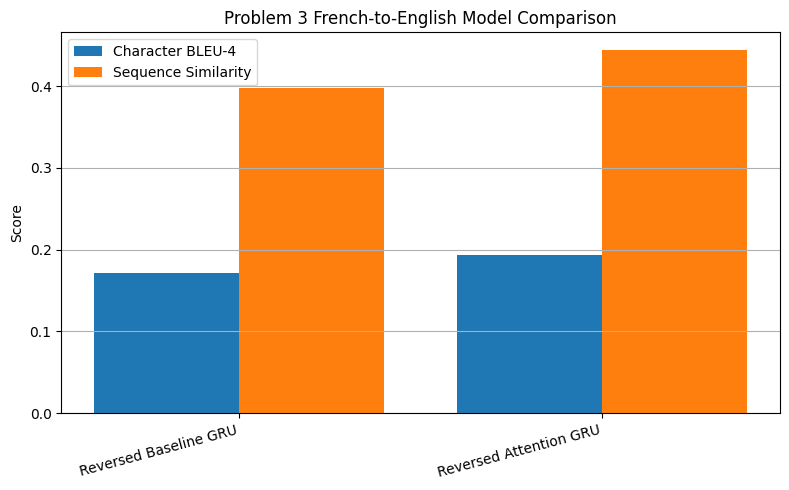

In [15]:
plt.figure(figsize=(8, 5))
x = np.arange(len(summary_df))
plt.bar(x - 0.2, summary_df['validation_bleu4_char_level'], width=0.4, label='Character BLEU-4')
plt.bar(x + 0.2, summary_df['validation_sequence_similarity'], width=0.4, label='Sequence Similarity')
plt.xticks(x, summary_df['model'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Problem 3 French-to-English Model Comparison')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem3_model_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

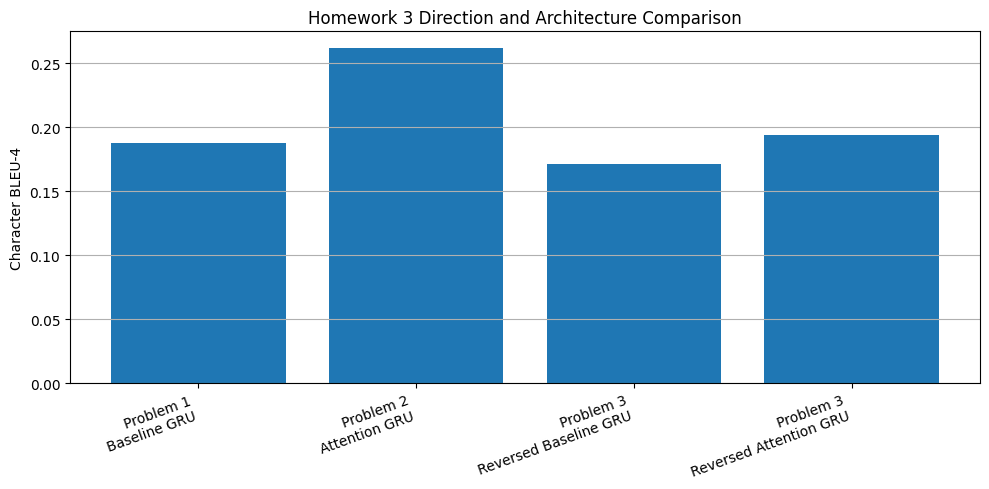

,problem,model,direction,exact_accuracy,char_accuracy,sequence_similarity,char_bleu4,word_bleu4,best_validation_loss,training_time_sec,total_params
0,Problem 1,Baseline GRU,English to French,0.000000,0.161757,NaN,0.188116,0.050088,1.411489,61.771480,332208
1,Problem 2,Attention GRU,English to French,0.009009,0.237327,0.489935,0.262004,0.089938,1.435507,259.549160,666929
2,Problem 3,Reversed Baseline GRU,French to English,0.000000,0.181316,0.397232,0.171086,0.062269,1.377312,202.588634,332689
3,Problem 3,Reversed Attention GRU,French to English,0.000000,0.208325,0.443528,0.194010,0.072555,1.474844,527.796173,666929


In [16]:
comparison_rows = []

if os.path.exists(problem1_summary_file):
    p1 = pd.read_csv(problem1_summary_file).iloc[0].to_dict()
    comparison_rows.append({
        'problem': 'Problem 1',
        'model': 'Baseline GRU',
        'direction': 'English to French',
        'exact_accuracy': p1.get('traditional_sequence_accuracy', np.nan),
        'char_accuracy': p1.get('validation_character_accuracy', np.nan),
        'sequence_similarity': p1.get('validation_sequence_similarity', np.nan),
        'char_bleu4': p1.get('validation_bleu4_char_level', np.nan),
        'word_bleu4': p1.get('validation_bleu4_word_level', np.nan),
        'best_validation_loss': p1.get('best_validation_loss', np.nan),
        'training_time_sec': p1.get('training_time_sec', np.nan),
        'total_params': p1.get('total_params', np.nan)
    })

if os.path.exists(problem2_summary_file):
    p2 = pd.read_csv(problem2_summary_file).iloc[0].to_dict()
    comparison_rows.append({
        'problem': 'Problem 2',
        'model': 'Attention GRU',
        'direction': 'English to French',
        'exact_accuracy': p2.get('traditional_sequence_accuracy', np.nan),
        'char_accuracy': p2.get('validation_character_accuracy', np.nan),
        'sequence_similarity': p2.get('validation_sequence_similarity', np.nan),
        'char_bleu4': p2.get('validation_bleu4_char_level', np.nan),
        'word_bleu4': p2.get('validation_bleu4_word_level', np.nan),
        'best_validation_loss': p2.get('best_validation_loss', np.nan),
        'training_time_sec': p2.get('training_time_sec', np.nan),
        'total_params': p2.get('total_params', np.nan)
    })

for _, row in summary_df.iterrows():
    comparison_rows.append({
        'problem': 'Problem 3',
        'model': row['model'],
        'direction': 'French to English',
        'exact_accuracy': row['traditional_sequence_accuracy'],
        'char_accuracy': row['validation_character_accuracy'],
        'sequence_similarity': row['validation_sequence_similarity'],
        'char_bleu4': row['validation_bleu4_char_level'],
        'word_bleu4': row['validation_bleu4_word_level'],
        'best_validation_loss': row['best_validation_loss'],
        'training_time_sec': row['training_time_sec'],
        'total_params': row['total_params']
    })

full_comparison_df = pd.DataFrame(comparison_rows)
full_comparison_df.to_csv(os.path.join(results_folder, 'problem3_full_direction_comparison.csv'), index=False)

plt.figure(figsize=(10, 5))
x = np.arange(len(full_comparison_df))
plt.bar(x, full_comparison_df['char_bleu4'])
plt.xticks(x, full_comparison_df['problem'] + '\n' + full_comparison_df['model'], rotation=20, ha='right')
plt.ylabel('Character BLEU-4')
plt.title('Homework 3 Direction and Architecture Comparison')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem3_full_bleu_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

full_comparison_df

In [17]:
baseline_row = summary_df[summary_df['model'] == 'Reversed Baseline GRU'].iloc[0]
attention_row = summary_df[summary_df['model'] == 'Reversed Attention GRU'].iloc[0]

p2_attention_bleu = np.nan
p2_attention_sim = np.nan
if os.path.exists(problem2_summary_file):
    p2_row = pd.read_csv(problem2_summary_file).iloc[0]
    p2_attention_bleu = p2_row.get('validation_bleu4_char_level', np.nan)
    p2_attention_sim = p2_row.get('validation_sequence_similarity', np.nan)

synthesis_text = (
    f"For the reversed French-to-English direction, the attention model performed better than the reversed baseline. "
    f"The reversed baseline GRU reached a character BLEU-4 score of {baseline_row['validation_bleu4_char_level']:.4f}, "
    f"while the reversed attention GRU reached {attention_row['validation_bleu4_char_level']:.4f}. The reversed attention "
    f"model also reached a sequence similarity score of {attention_row['validation_sequence_similarity'] * 100:.2f}%, "
    f"so its generated English sentences were closer to the targets even when they were not exact matches. However, comparing "
    f"the best attention models across directions, English-to-French was more effective in this experiment: Problem 2 reached "
    f"a character BLEU-4 of {p2_attention_bleu:.4f}, while the reversed French-to-English attention model reached "
    f"{attention_row['validation_bleu4_char_level']:.4f}. Exact sentence accuracy stayed low because one wrong character, "
    f"accent, word ending, or word order difference makes the whole sentence fail. The result suggests that attention improves "
    f"both directions, but this split and small dataset still favored the original English-to-French setup overall."
)

print(synthesis_text)
with open(os.path.join(results_folder, 'problem3_synthesis_paragraph.txt'), 'w', encoding='utf-8') as f:
    f.write(synthesis_text)

For the reversed French-to-English direction, the attention model performed better than the reversed baseline. The reversed baseline GRU reached a character BLEU-4 score of 0.1711, while the reversed attention GRU reached 0.1940. The reversed attention model also reached a sequence similarity score of 44.35%, so its generated English sentences were closer to the targets even when they were not exact matches. However, comparing the best attention models across directions, English-to-French was more effective in this experiment: Problem 2 reached a character BLEU-4 of 0.2620, while the reversed French-to-English attention model reached 0.1940. Exact sentence accuracy stayed low because one wrong character, accent, word ending, or word order difference makes the whole sentence fail. The result suggests that attention improves both directions, but this split and small dataset still favored the original English-to-French setup overall.


## Report Reminder

Use the CSVs and plots in `Results_Problem_3` for the final report. The most important files are:

- `problem3_summary.csv`
- `problem3_baseline_loss_curve.png`
- `problem3_attention_loss_curve.png`
- `problem3_attention_map_1.png` and `problem3_attention_map_2.png`
- `problem3_full_direction_comparison.csv`
- `problem3_synthesis_paragraph.txt`